In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv1D, MaxPooling1D, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import TimeSeriesSplit
from darts.models import NBEATSModel
from darts import TimeSeries
import xgboost as xgb

# Step 1: Load Data
def load_data_india():
    dataset = pd.read_excel('All_India_CPI_2013_2025.xlsx')
    dataset = dataset.melt(id_vars='Year', var_name='Month', value_name='CPI')
    month_map = {
        'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04', 'May': '05', 'Jun': '06',
        'Jul': '07', 'Aug': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'
    }
    dataset['Month'] = dataset['Month'].map(month_map)
    dataset['Date'] = pd.to_datetime(dataset['Year'].astype(str) + '-' + dataset['Month'] + '-01') + pd.offsets.MonthEnd(1)
    dataset.sort_values(by='Date', ascending=True, inplace=True)
    dataset.drop(['Year', 'Month'], axis=1, inplace=True)
    dataset.set_index('Date', inplace=True)
    dataset.dropna(subset=['CPI'], inplace=True)  # Drop rows with missing CPI (e.g., Feb 2025 onward)
    if not dataset['CPI'].isna().any() and not dataset['CPI'].isin([float('inf'), -float('inf')]).any():
        print("Data is clean: No NaN or inf values in CPI")
    return dataset

df = load_data_india()
print(f"Data shape: {df.shape}")
print("Indian CPI Data (last 5 rows):")
print(df.tail())

ModuleNotFoundError: No module named 'darts'

In [2]:
!pip install darts xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.0/340.0 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv1D, MaxPooling1D, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import TimeSeriesSplit
from darts.models import NBEATSModel
from darts import TimeSeries
import xgboost as xgb

# Step 1: Load Data
def load_data_india():
    dataset = pd.read_excel('All_India_CPI_2013_2025.xlsx')
    dataset = dataset.melt(id_vars='Year', var_name='Month', value_name='CPI')
    month_map = {
        'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04', 'May': '05', 'Jun': '06',
        'Jul': '07', 'Aug': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'
    }
    dataset['Month'] = dataset['Month'].map(month_map)
    dataset['Date'] = pd.to_datetime(dataset['Year'].astype(str) + '-' + dataset['Month'] + '-01') + pd.offsets.MonthEnd(1)
    dataset.sort_values(by='Date', ascending=True, inplace=True)
    dataset.drop(['Year', 'Month'], axis=1, inplace=True)
    dataset.set_index('Date', inplace=True)
    dataset.dropna(subset=['CPI'], inplace=True)  # Drop rows with missing CPI (e.g., Feb 2025 onward)
    if not dataset['CPI'].isna().any() and not dataset['CPI'].isin([float('inf'), -float('inf')]).any():
        print("Data is clean: No NaN or inf values in CPI")
    return dataset

df = load_data_india()
print(f"Data shape: {df.shape}")
print("Indian CPI Data (last 5 rows):")
print(df.tail())

# Step 2: Differencing and Normalization
series = df['CPI'].diff().dropna()  # First-order differencing for stationarity
train_size = int(0.8 * len(series))
train_data, val_data = series[:train_size], series[train_size:]
scaler = MinMaxScaler(feature_range=(0, 1))
train_data_scaled = scaler.fit_transform(train_data.values.reshape(-1, 1))
val_data_scaled = scaler.transform(val_data.values.reshape(-1, 1))  # Avoid data leakage
norm_df = np.concatenate([train_data_scaled, val_data_scaled])
joblib.dump(scaler, 'scaler_india.pkl')
print('Normalized data shape:', norm_df.shape)

Data is clean: No NaN or inf values in CPI
Data shape: (146, 1)
Indian CPI Data (last 5 rows):
              CPI
Date             
2024-10-31  196.8
2024-11-30  196.5
2024-12-31  195.4
2025-01-31  193.4
2025-02-28  192.5
Normalized data shape: (145, 1)


In [2]:
# Step 3: Sequence Creation
def create_sequences(data, n_lags):
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i - n_lags:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

In [3]:

# Step 4: Test Different Sequence Lengths
n_lags_list = [6, 12, 24]
results = []  # Initialize results list

for n_lags in n_lags_list:
    print(f"\nTesting sequence length: {n_lags}")
    X, y = create_sequences(norm_df, n_lags)
    if len(X) == 0:
        print(f"Skipping n_lags={n_lags} due to insufficient data")
        continue
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))
    y = np.reshape(y, (y.shape[0], 1))
    print('X shape:', X.shape)
    print('y shape:', y.shape)

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=5)
    cnn_results, lstm_results, cnn_lstm_results, nbeats_results, xgboost_results = [], [], [], [], []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        print(f'Train shapes: X={X_train.shape}, y={y_train.shape}')
        print(f'Validation shapes: X={X_val.shape}, y={y_val.shape}')

        # CNN Model
        cnn = Sequential([
            Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_lags, 1)),
            Conv1D(filters=32, kernel_size=3, activation='relu'),
            MaxPooling1D(pool_size=2),
            Dropout(0.2),
            Flatten(),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        cnn.compile(optimizer='adam', loss='mean_squared_error')
        cnn_history = cnn.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                              callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                         ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

        # LSTM Model
        lstm = Sequential([
            LSTM(units=64, return_sequences=True, input_shape=(n_lags, 1)),
            Dropout(0.2),
            LSTM(units=32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        lstm.compile(optimizer='adam', loss='mean_squared_error')
        lstm_history = lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                                callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                           ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

        # CNN-LSTM Hybrid Model
        cnn_lstm = Sequential([
            Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(n_lags, 1)),
            MaxPooling1D(pool_size=2),
            LSTM(units=32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        cnn_lstm.compile(optimizer='adam', loss='mean_squared_error')
        cnn_lstm_history = cnn_lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                                        callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                                   ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

        # N-BEATS Model
        nbeats = NBEATSModel(input_chunk_length=n_lags, output_chunk_length=1, generic_architecture=True,
                             num_stacks=2, num_blocks=3, num_layers=4, layer_widths=512, n_epochs=100,
                             random_state=42)
        nbeats.fit(TimeSeries.from_values(y_train.flatten()), epochs=100, verbose=True)

        # XGBoost Model
        X_train_2d = X_train.reshape(X_train.shape[0], X_train.shape[1])  # Reshape for XGBoost
        X_val_2d = X_val.reshape(X_val.shape[0], X_val.shape[1])
        xgboost = xgb.XGBRegressor(n_estimators=1000, objective='reg:squarederror', random_state=42)
        xgboost.fit(X_train_2d, y_train.flatten())

        # Evaluate
        cnn_val_pred = scaler.inverse_transform(cnn.predict(X_val, verbose=0))
        lstm_val_pred = scaler.inverse_transform(lstm.predict(X_val, verbose=0))
        cnn_lstm_val_pred = scaler.inverse_transform(cnn_lstm.predict(X_val, verbose=0))
        nbeats_val_pred = scaler.inverse_transform(nbeats.predict(n=len(X_val), series=TimeSeries.from_values(y_train.flatten())).values())
        xgboost_val_pred = scaler.inverse_transform(xgboost.predict(X_val_2d).reshape(-1, 1))
        true_val = scaler.inverse_transform(y_val)

        cnn_results.append(mean_absolute_error(true_val, cnn_val_pred))
        lstm_results.append(mean_absolute_error(true_val, lstm_val_pred))
        cnn_lstm_results.append(mean_absolute_error(true_val, cnn_lstm_val_pred))
        nbeats_results.append(mean_absolute_error(true_val, nbeats_val_pred))
        xgboost_results.append(mean_absolute_error(true_val, xgboost_val_pred))

    print(f"Average CNN MAE (n_lags={n_lags}): {np.mean(cnn_results):.4f}")
    print(f"Average LSTM MAE (n_lags={n_lags}): {np.mean(lstm_results):.4f}")
    print(f"Average CNN-LSTM MAE (n_lags={n_lags}): {np.mean(cnn_lstm_results):.4f}")
    print(f"Average N-BEATS MAE (n_lags={n_lags}): {np.mean(nbeats_results):.4f}")
    print(f"Average XGBoost MAE (n_lags={n_lags}): {np.mean(xgboost_results):.4f}")
    results.append({
        'n_lags': n_lags,
        'cnn_mae': np.mean(cnn_results),
        'lstm_mae': np.mean(lstm_results),
        'cnn_lstm_mae': np.mean(cnn_lstm_results),
        'nbeats_mae': np.mean(nbeats_results),
        'xgboost_mae': np.mean(xgboost_results)
    })



Testing sequence length: 6
X shape: (139, 6, 1)
y shape: (139, 1)
Train shapes: X=(24, 6, 1), y=(24, 1)
Validation shapes: X=(23, 6, 1), y=(23, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 637ms/step - loss: 0.2694 - val_loss: 0.1640 - learning_rate: 0.0010
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - loss: 0.2018 - val_loss: 0.1156 - learning_rate: 0.0010
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - loss: 0.1441 - val_loss: 0.0764 - learning_rate: 0.0010
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.1091 - val_loss: 0.0473 - learning_rate: 0.0010
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - loss: 0.0718 - val_loss: 0.0292 - learning_rate: 0.0010
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - loss: 0.0727 - val_loss: 0.0219 - learning_rate: 0.0010
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 0.0679 - val_loss: 0.0226 - learning_rate: 0.0010
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - loss: 0.0640 - val_loss: 0.0266 - learning_rate: 0.0010
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.0560 - val_loss: 0.0292 - learning_rate: 0.0010
Epoch 10/100
2/2 ━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 582ms/step - loss: 0.2739 - val_loss: 0.1810 - learning_rate: 0.0010
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.2198 - val_loss: 0.1370 - learning_rate: 0.0010
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1792 - val_loss: 0.0964 - learning_rate: 0.0010
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1234 - val_loss: 0.0614 - learning_rate: 0.0010
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0916 - val_loss: 0.0351 - learning_rate: 0.0010
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.0684 - val_loss: 0.0222 - learning_rate: 0.0010
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0589 - val_loss: 0.0260 - learning_rate: 0.0010
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0604 - val_loss: 0.0378 - learning_rate: 0.0010
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.0678 - val_loss: 0.0400 - learning_rate: 0.0010
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━

...

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - loss: 0.2888 - val_loss: 0.1820 - learning_rate: 0.0010
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.2106 - val_loss: 0.1333 - learning_rate: 0.0010
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.1550 - val_loss: 0.0853 - learning_rate: 0.0010
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0927 - val_loss: 0.0462 - learning_rate: 0.0010
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0433 - val_loss: 0.0266 - learning_rate: 0.0010
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0199 - val_loss: 0.0352 - learning_rate: 0.0010
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0218 - val_loss: 0.0559 - learning_rate: 0.0010
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0450 - val_loss: 0.0588 - learning_rate: 0.0010
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0437 - val_loss: 0.0471 - learning_rate: 0.0010
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 611ms/step - loss: 0.2522 - val_loss: 0.1566 - learning_rate: 0.0010
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.1666 - val_loss: 0.1034 - learning_rate: 0.0010
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.1166 - val_loss: 0.0543 - learning_rate: 0.0010
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0504 - val_loss: 0.0263 - learning_rate: 0.0010
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0299 - val_loss: 0.0456 - learning_rate: 0.0010
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.0340 - val_loss: 0.0644 - learning_rate: 0.0010
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0642 - val_loss: 0.0462 - learning_rate: 0.0010
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0474 - val_loss: 0.0302 - learning_rate: 0.0010
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0270 - val_loss: 0.0259 - learning_rate: 0.0010
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━

ERROR:main_logger:ValueError: The input `series` are too short to extract even a single sample. Expected min length: `25`, received max length: `21`.


ValueError: The input `series` are too short to extract even a single sample. Expected min length: `25`, received max length: `21`.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv1D, MaxPooling1D, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import TimeSeriesSplit
from darts.models import NBEATSModel
from darts import TimeSeries
import xgboost as xgb


In [5]:

# Step 1: Load Data
def load_data_india():
    dataset = pd.read_excel('All_India_CPI_2013_2025.xlsx')
    dataset = dataset.melt(id_vars='Year', var_name='Month', value_name='CPI')
    month_map = {
        'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04', 'May': '05', 'Jun': '06',
        'Jul': '07', 'Aug': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'
    }
    dataset['Month'] = dataset['Month'].map(month_map)
    dataset['Date'] = pd.to_datetime(dataset['Year'].astype(str) + '-' + dataset['Month'] + '-01') + pd.offsets.MonthEnd(1)
    dataset.sort_values(by='Date', ascending=True, inplace=True)
    dataset.drop(['Year', 'Month'], axis=1, inplace=True)
    dataset.set_index('Date', inplace=True)
    dataset.dropna(subset=['CPI'], inplace=True)  # Drop rows with missing CPI (e.g., Feb 2025 onward)
    if not dataset['CPI'].isna().any() and not dataset['CPI'].isin([float('inf'), -float('inf')]).any():
        print("Data is clean: No NaN or inf values in CPI")
    return dataset

df = load_data_india()
print(f"Data shape: {df.shape}")
print("Indian CPI Data (last 5 rows):")
print(df.tail())


Data is clean: No NaN or inf values in CPI
Data shape: (146, 1)
Indian CPI Data (last 5 rows):
              CPI
Date             
2024-10-31  196.8
2024-11-30  196.5
2024-12-31  195.4
2025-01-31  193.4
2025-02-28  192.5


In [6]:

# Step 2: Differencing and Normalization
series = df['CPI'].diff().dropna()  # First-order differencing for stationarity
train_size = int(0.8 * len(series))
train_data, val_data = series[:train_size], series[train_size:]
scaler = MinMaxScaler(feature_range=(0, 1))
train_data_scaled = scaler.fit_transform(train_data.values.reshape(-1, 1))
val_data_scaled = scaler.transform(val_data.values.reshape(-1, 1))  # Avoid data leakage
norm_df = np.concatenate([train_data_scaled, val_data_scaled])
joblib.dump(scaler, 'scaler_india.pkl')
print('Normalized data shape:', norm_df.shape)

Normalized data shape: (145, 1)


In [7]:
# Step 3: Sequence Creation
def create_sequences(data, n_lags):
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i - n_lags:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


In [8]:

# Step 4: Test Different Sequence Lengths
n_lags_list = [6, 12, 24]
results = []  # Initialize results list

for n_lags in n_lags_list:
    print(f"\nTesting sequence length: {n_lags}")
    X, y = create_sequences(norm_df, n_lags)
    if len(X) == 0:
        print(f"Skipping n_lags={n_lags} due to insufficient data")
        continue
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))
    y = np.reshape(y, (y.shape[0], 1))
    print('X shape:', X.shape)
    print('y shape:', y.shape)

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=3)  # Reduced to 3 splits to ensure sufficient training data
    cnn_results, lstm_results, cnn_lstm_results, nbeats_results, xgboost_results = [], [], [], [], []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        print(f'Train shapes: X={X_train.shape}, y={y_train.shape}')
        print(f'Validation shapes: X={X_val.shape}, y={y_val.shape}')

        # CNN Model
        cnn = Sequential([
            Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_lags, 1)),
            Conv1D(filters=32, kernel_size=3, activation='relu'),
            MaxPooling1D(pool_size=2),
            Dropout(0.2),
            Flatten(),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        cnn.compile(optimizer='adam', loss='mean_squared_error')
        cnn_history = cnn.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                              callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                         ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

        # LSTM Model
        lstm = Sequential([
            LSTM(units=64, return_sequences=True, input_shape=(n_lags, 1)),
            Dropout(0.2),
            LSTM(units=32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        lstm.compile(optimizer='adam', loss='mean_squared_error')
        lstm_history = lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                                callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                           ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

        # CNN-LSTM Hybrid Model
        cnn_lstm = Sequential([
            Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(n_lags, 1)),
            MaxPooling1D(pool_size=2),
            LSTM(units=32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        cnn_lstm.compile(optimizer='adam', loss='mean_squared_error')
        cnn_lstm_history = cnn_lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                                        callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                                   ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

        # N-BEATS Model
        if len(y_train) >= n_lags + 1:  # Ensure sufficient length for N-BEATS
            nbeats = NBEATSModel(input_chunk_length=n_lags, output_chunk_length=1, generic_architecture=True,
                                 num_stacks=2, num_blocks=3, num_layers=4, layer_widths=512, n_epochs=100,
                                 random_state=42)
            nbeats.fit(TimeSeries.from_values(y_train.flatten()), epochs=100, verbose=True)
        else:
            print(f"Skipping N-BEATS for n_lags={n_lags} in this fold due to insufficient training data length: {len(y_train)}")
            nbeats_val_pred = np.zeros_like(y_val)  # Placeholder for skipped fold
            nbeats_results.append(np.nan)

        # XGBoost Model
        X_train_2d = X_train.reshape(X_train.shape[0], X_train.shape[1])  # Reshape for XGBoost
        X_val_2d = X_val.reshape(X_val.shape[0], X_val.shape[1])
        xgboost = xgb.XGBRegressor(n_estimators=1000, objective='reg:squarederror', random_state=42)
        xgboost.fit(X_train_2d, y_train.flatten())

        # Evaluate
        cnn_val_pred = scaler.inverse_transform(cnn.predict(X_val, verbose=0))
        lstm_val_pred = scaler.inverse_transform(lstm.predict(X_val, verbose=0))
        cnn_lstm_val_pred = scaler.inverse_transform(cnn_lstm.predict(X_val, verbose=0))
        if len(y_train) >= n_lags + 1:
            nbeats_val_pred = scaler.inverse_transform(nbeats.predict(n=len(X_val), series=TimeSeries.from_values(y_train.flatten())).values())
        else:
            nbeats_val_pred = np.zeros_like(y_val)  # Placeholder for skipped fold
        xgboost_val_pred = scaler.inverse_transform(xgboost.predict(X_val_2d).reshape(-1, 1))
        true_val = scaler.inverse_transform(y_val)

        cnn_results.append(mean_absolute_error(true_val, cnn_val_pred))
        lstm_results.append(mean_absolute_error(true_val, lstm_val_pred))
        cnn_lstm_results.append(mean_absolute_error(true_val, cnn_lstm_val_pred))
        if len(y_train) >= n_lags + 1:
            nbeats_results[-1] = mean_absolute_error(true_val, nbeats_val_pred)  # Replace placeholder if valid
        xgboost_results.append(mean_absolute_error(true_val, xgboost_val_pred))

    print(f"Average CNN MAE (n_lags={n_lags}): {np.nanmean(cnn_results):.4f}")
    print(f"Average LSTM MAE (n_lags={n_lags}): {np.nanmean(lstm_results):.4f}")
    print(f"Average CNN-LSTM MAE (n_lags={n_lags}): {np.nanmean(cnn_lstm_results):.4f}")
    print(f"Average N-BEATS MAE (n_lags={n_lags}): {np.nanmean(nbeats_results):.4f}")
    print(f"Average XGBoost MAE (n_lags={n_lags}): {np.nanmean(xgboost_results):.4f}")
    results.append({
        'n_lags': n_lags,
        'cnn_mae': np.nanmean(cnn_results),
        'lstm_mae': np.nanmean(lstm_results),
        'cnn_lstm_mae': np.nanmean(cnn_lstm_results),
        'nbeats_mae': np.nanmean(nbeats_results),
        'xgboost_mae': np.nanmean(xgboost_results)
    })


Testing sequence length: 6
X shape: (139, 6, 1)
y shape: (139, 1)
Train shapes: X=(37, 6, 1), y=(37, 1)
Validation shapes: X=(34, 6, 1), y=(34, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - loss: 0.2776 - val_loss: 0.2108 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2592 - val_loss: 0.1822 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2154 - val_loss: 0.1530 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1835 - val_loss: 0.1213 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1605 - val_loss: 0.0874 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1037 - val_loss: 0.0549 - learning_rate: 0.0010
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0784 - val_loss: 0.0310 - learning_rate: 0.0010
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0521 - val_loss: 0.0235 - learning_rate: 0.0010
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0477 - val_loss: 0.0302 - learning_rate: 0.0010
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 303ms/step - loss: 0.2731 - val_loss: 0.1903 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.2291 - val_loss: 0.1546 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1959 - val_loss: 0.1182 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1541 - val_loss: 0.0827 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1064 - val_loss: 0.0511 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0747 - val_loss: 0.0310 - learning_rate: 0.0010
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0543 - val_loss: 0.0269 - learning_rate: 0.0010
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0379 - val_loss: 0.0336 - learning_rate: 0.0010
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0381 - val_loss: 0.0369 - learning_rate: 0.0010
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 4.8 M  | train
-------------------------------------------------------------
4.8 M     Trainable params
2.6 K     Non-trainable params
4.8 M     Total params
19.121    Total estimated model params size (MB)
76        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

IndexError: list assignment index out of range

In [9]:

# Step 4: Test Different Sequence Lengths
n_lags_list = [6, 12, 24]
results = []  # Initialize results list

for n_lags in n_lags_list:
    print(f"\nTesting sequence length: {n_lags}")
    X, y = create_sequences(norm_df, n_lags)
    if len(X) == 0:
        print(f"Skipping n_lags={n_lags} due to insufficient data")
        continue
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))
    y = np.reshape(y, (y.shape[0], 1))
    print('X shape:', X.shape)
    print('y shape:', y.shape)

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=3)  # Reduced to 3 splits to ensure sufficient training data
    cnn_results, lstm_results, cnn_lstm_results, nbeats_results, xgboost_results = [], [], [], [], []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        print(f'Train shapes: X={X_train.shape}, y={y_train.shape}')
        print(f'Validation shapes: X={X_val.shape}, y={y_val.shape}')

        # CNN Model
        cnn = Sequential([
            Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_lags, 1)),
            Conv1D(filters=32, kernel_size=3, activation='relu'),
            MaxPooling1D(pool_size=2),
            Dropout(0.2),
            Flatten(),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        cnn.compile(optimizer='adam', loss='mean_squared_error')
        cnn_history = cnn.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                              callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                         ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

        # LSTM Model
        lstm = Sequential([
            LSTM(units=64, return_sequences=True, input_shape=(n_lags, 1)),
            Dropout(0.2),
            LSTM(units=32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        lstm.compile(optimizer='adam', loss='mean_squared_error')
        lstm_history = lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                                callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                           ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

        # CNN-LSTM Hybrid Model
        cnn_lstm = Sequential([
            Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(n_lags, 1)),
            MaxPooling1D(pool_size=2),
            LSTM(units=32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        cnn_lstm.compile(optimizer='adam', loss='mean_squared_error')
        cnn_lstm_history = cnn_lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                                        callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                                   ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

        # N-BEATS Model
        cnn_val_pred = scaler.inverse_transform(cnn.predict(X_val, verbose=0))
        lstm_val_pred = scaler.inverse_transform(lstm.predict(X_val, verbose=0))
        cnn_lstm_val_pred = scaler.inverse_transform(cnn_lstm.predict(X_val, verbose=0))
        true_val = scaler.inverse_transform(y_val)

        if len(y_train) >= n_lags + 1:  # Ensure sufficient length for N-BEATS
            nbeats = NBEATSModel(input_chunk_length=n_lags, output_chunk_length=1, generic_architecture=True,
                                 num_stacks=2, num_blocks=3, num_layers=4, layer_widths=512, n_epochs=100,
                                 random_state=42)
            nbeats.fit(TimeSeries.from_values(y_train.flatten()), epochs=100, verbose=True)
            nbeats_val_pred = scaler.inverse_transform(nbeats.predict(n=len(X_val), series=TimeSeries.from_values(y_train.flatten())).values())
            nbeats_results.append(mean_absolute_error(true_val, nbeats_val_pred))
        else:
            print(f"Skipping N-BEATS for n_lags={n_lags} in this fold due to insufficient training data length: {len(y_train)}")
            nbeats_results.append(np.nan)

        # XGBoost Model
        X_train_2d = X_train.reshape(X_train.shape[0], X_train.shape[1])  # Reshape for XGBoost
        X_val_2d = X_val.reshape(X_val.shape[0], X_val.shape[1])
        xgboost = xgb.XGBRegressor(n_estimators=1000, objective='reg:squarederror', random_state=42)
        xgboost.fit(X_train_2d, y_train.flatten())
        xgboost_val_pred = scaler.inverse_transform(xgboost.predict(X_val_2d).reshape(-1, 1))

        # Evaluate
        cnn_results.append(mean_absolute_error(true_val, cnn_val_pred))
        lstm_results.append(mean_absolute_error(true_val, lstm_val_pred))
        cnn_lstm_results.append(mean_absolute_error(true_val, cnn_lstm_val_pred))
        xgboost_results.append(mean_absolute_error(true_val, xgboost_val_pred))

    print(f"Average CNN MAE (n_lags={n_lags}): {np.nanmean(cnn_results):.4f}")
    print(f"Average LSTM MAE (n_lags={n_lags}): {np.nanmean(lstm_results):.4f}")
    print(f"Average CNN-LSTM MAE (n_lags={n_lags}): {np.nanmean(cnn_lstm_results):.4f}")
    print(f"Average N-BEATS MAE (n_lags={n_lags}): {np.nanmean(nbeats_results):.4f}")
    print(f"Average XGBoost MAE (n_lags={n_lags}): {np.nanmean(xgboost_results):.4f}")
    results.append({
        'n_lags': n_lags,
        'cnn_mae': np.nanmean(cnn_results),
        'lstm_mae': np.nanmean(lstm_results),
        'cnn_lstm_mae': np.nanmean(cnn_lstm_results),
        'nbeats_mae': np.nanmean(nbeats_results),
        'xgboost_mae': np.nanmean(xgboost_results)
    })


Testing sequence length: 6
X shape: (139, 6, 1)
y shape: (139, 1)
Train shapes: X=(37, 6, 1), y=(37, 1)
Validation shapes: X=(34, 6, 1), y=(34, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 0.2297 - val_loss: 0.1282 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1559 - val_loss: 0.0807 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1022 - val_loss: 0.0469 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0626 - val_loss: 0.0292 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0525 - val_loss: 0.0273 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0547 - val_loss: 0.0328 - learning_rate: 0.0010
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0471 - val_loss: 0.0355 - learning_rate: 0.0010
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0520 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0537 - val_loss: 0.0263 - learning_rate: 0.0010
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - loss: 0.2783 - val_loss: 0.1685 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.2036 - val_loss: 0.1066 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1153 - val_loss: 0.0566 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0869 - val_loss: 0.0287 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0532 - val_loss: 0.0324 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0484 - val_loss: 0.0407 - learning_rate: 0.0010
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0581 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0723 - val_loss: 0.0258 - learning_rate: 0.0010
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0521 - val_loss: 0.0263 - learning_rate: 0.0010
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 4.8 M  | train
-------------------------------------------------------------
4.8 M     Trainable params
2.7 K     Non-trainable params
4.8 M     Total params
19.345    Total estimated model params size (MB)
76        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Average CNN MAE (n_lags=24): 0.8271
Average LSTM MAE (n_lags=24): 0.8609
Average CNN-LSTM MAE (n_lags=24): 0.8764
Average N-BEATS MAE (n_lags=24): 0.9546
Average XGBoost MAE (n_lags=24): 0.8016


In [10]:
# Step 5: Select Best Sequence Length
if not results:
    raise ValueError("No results generated. Check data or sequence lengths.")
best_n_lags = min(results, key=lambda x: x['nbeats_mae'] if not np.isnan(x['nbeats_mae']) else float('inf'))['n_lags']  # Handle NaN for N-BEATS
print(f"\nBest sequence length: {best_n_lags}")


Best sequence length: 6


In [11]:

# Step 6: Train Final Models with Best Sequence Length
X, y = create_sequences(norm_df, best_n_lags)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
y = np.reshape(y, (y.shape[0], 1))
train_size = int(0.8 * len(X))
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]
print(f'Final train shapes: X={X_train.shape}, y={y_train.shape}')
print(f'Final validation shapes: X={X_val.shape}, y={y_val.shape}')

# Final CNN
cnn = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(best_n_lags, 1)),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])
cnn.compile(optimizer='adam', loss='mean_squared_error')
cnn_history = cnn.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                      callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                 ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

# Final LSTM
lstm = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(best_n_lags, 1)),
    Dropout(0.2),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mean_squared_error')
lstm_history = lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                        callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                   ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

# Final CNN-LSTM
cnn_lstm = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(best_n_lags, 1)),
    MaxPooling1D(pool_size=2),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
cnn_lstm.compile(optimizer='adam', loss='mean_squared_error')
cnn_lstm_history = cnn_lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                                callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                           ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

# Final N-BEATS
nbeats = NBEATSModel(input_chunk_length=best_n_lags, output_chunk_length=1, generic_architecture=True,
                     num_stacks=2, num_blocks=3, num_layers=4, layer_widths=512, n_epochs=100, random_state=42)
nbeats.fit(TimeSeries.from_values(y_train.flatten()), epochs=100, verbose=True)

# Final XGBoost
X_train_2d = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_val_2d = X_val.reshape(X_val.shape[0], X_val.shape[1])
xgboost = xgb.XGBRegressor(n_estimators=1000, objective='reg:squarederror', random_state=42)
xgboost.fit(X_train_2d, y_train.flatten())


Final train shapes: X=(111, 6, 1), y=(111, 1)
Final validation shapes: X=(28, 6, 1), y=(28, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.3654 - val_loss: 0.3307 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2512 - val_loss: 0.2626 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1974 - val_loss: 0.1932 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1280 - val_loss: 0.1405 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0701 - val_loss: 0.1512 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0514 - val_loss: 0.1665 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0585 - val_loss: 0.1398 - learning_rate: 0.0010
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0577 - val_loss: 0.1312 - learning_rate: 0.0010
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0564 - val_loss: 0.1293 - learning_rate: 0.0010
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 0.2880 - val_loss: 0.2446 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1495 - val_loss: 0.1408 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0635 - val_loss: 0.1595 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0772 - val_loss: 0.1329 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0413 - val_loss: 0.1270 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0546 - val_loss: 0.1259 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0506 - val_loss: 0.1263 - learning_rate: 0.0010
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0491 - val_loss: 0.1273 - learning_rate: 0.0010
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0446 - val_loss: 0.1235 - learning_rate: 0.0010
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 4.8 M  | train
-------------------------------------------------------------
4.8 M     Trainable params
2.6 K     Non-trainable params
4.8 M     Total params
19.121    Total estimated model params size (MB)
76        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

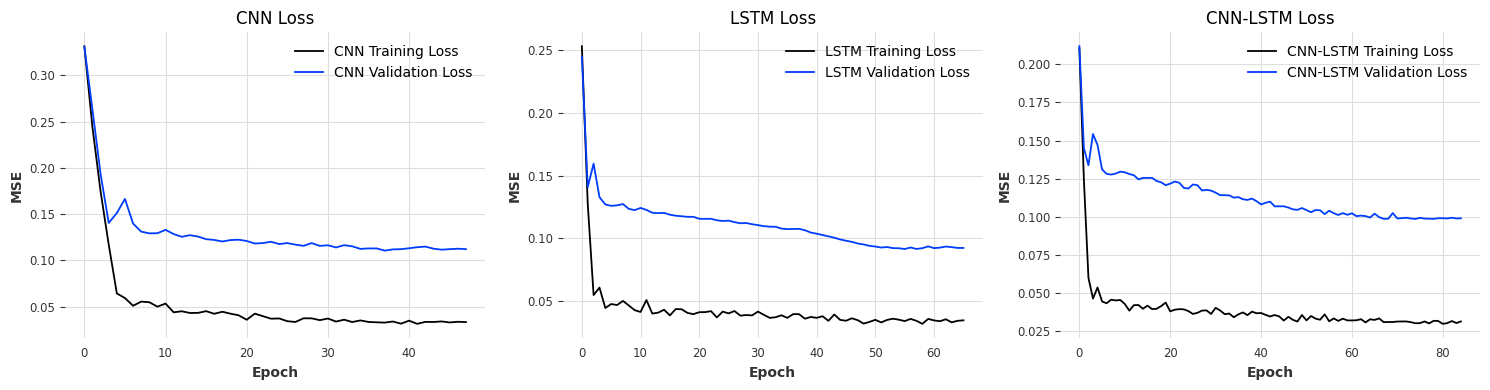

In [12]:

# Step 7: Plot Training History (for neural models)
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(cnn_history.history['loss'], label='CNN Training Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(lstm_history.history['loss'], label='LSTM Training Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(cnn_lstm_history.history['loss'], label='CNN-LSTM Training Loss')
plt.plot(cnn_lstm_history.history['val_loss'], label='CNN-LSTM Validation Loss')
plt.title('CNN-LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:

# Step 8: Evaluate Models on Validation Data
cnn_val_pred = cnn.predict(X_val, verbose=0)
lstm_val_pred = lstm.predict(X_val, verbose=0)
cnn_lstm_val_pred = cnn_lstm.predict(X_val, verbose=0)
nbeats_val_pred = nbeats.predict(n=len(X_val), series=TimeSeries.from_values(y_train.flatten())).values()
xgboost_val_pred = xgboost.predict(X_val_2d).reshape(-1, 1)

# Inverse transform and undifference
def inverse_transform_and_undifference(predictions, scaler, last_value):
    predictions = scaler.inverse_transform(predictions)
    return np.cumsum(np.concatenate([[last_value], predictions.flatten()]))[1:]

last_value = df['CPI'].iloc[train_size + best_n_lags - 1]  # Last CPI before validation
cnn_val_pred = inverse_transform_and_undifference(cnn_val_pred, scaler, last_value)
lstm_val_pred = inverse_transform_and_undifference(lstm_val_pred, scaler, last_value)
cnn_lstm_val_pred = inverse_transform_and_undifference(cnn_lstm_val_pred, scaler, last_value)
nbeats_val_pred = inverse_transform_and_undifference(nbeats_val_pred, scaler, last_value)
xgboost_val_pred = inverse_transform_and_undifference(xgboost_val_pred, scaler, last_value)
true_val = df['CPI'].iloc[train_size + best_n_lags:train_size + best_n_lags + len(cnn_val_pred)].values

# Debug shapes
print(f"Shape of true_val: {true_val.shape}")
print(f"Shape of cnn_val_pred: {cnn_val_pred.shape}")
print(f"Shape of lstm_val_pred: {lstm_val_pred.shape}")
print(f"Shape of cnn_lstm_val_pred: {cnn_lstm_val_pred.shape}")
print(f"Shape of nbeats_val_pred: {nbeats_val_pred.shape}")
print(f"Shape of xgboost_val_pred: {xgboost_val_pred.shape}")

print('\nCNN Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, cnn_val_pred))
r2 = r2_score(true_val, cnn_val_pred)
mae = mean_absolute_error(true_val, cnn_val_pred)
mape = mean_absolute_percentage_error(true_val, cnn_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')

print('\nLSTM Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, lstm_val_pred))
r2 = r2_score(true_val, lstm_val_pred)
mae = mean_absolute_error(true_val, lstm_val_pred)
mape = mean_absolute_percentage_error(true_val, lstm_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')

print('\nCNN-LSTM Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, cnn_lstm_val_pred))
r2 = r2_score(true_val, cnn_lstm_val_pred)
mae = mean_absolute_error(true_val, cnn_lstm_val_pred)
mape = mean_absolute_percentage_error(true_val, cnn_lstm_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')

print('\nN-BEATS Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, nbeats_val_pred))
r2 = r2_score(true_val, nbeats_val_pred)
mae = mean_absolute_error(true_val, nbeats_val_pred)
mape = mean_absolute_percentage_error(true_val, nbeats_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')

print('\nXGBoost Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, xgboost_val_pred))
r2 = r2_score(true_val, xgboost_val_pred)
mae = mean_absolute_error(true_val, xgboost_val_pred)
mape = mean_absolute_percentage_error(true_val, xgboost_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Shape of true_val: (28,)
Shape of cnn_val_pred: (28,)
Shape of lstm_val_pred: (28,)
Shape of cnn_lstm_val_pred: (28,)
Shape of nbeats_val_pred: (28,)
Shape of xgboost_val_pred: (28,)

CNN Validation Performance:
RMSE: 2.7023
R2: 0.8404
MAE: 2.0509
MAPE: 1.0841%

LSTM Validation Performance:
RMSE: 2.4939
R2: 0.8640
MAE: 1.9954
MAPE: 1.0566%

CNN-LSTM Validation Performance:
RMSE: 2.1795
R2: 0.8961
MAE: 1.7038
MAPE: 0.9011%

N-BEATS Validation Performance:
RMSE: 4.2823
R2: 0.5991
MAE: 3.5013
MAPE: 1.8591%

XGBoost Validation Performance:
RMSE: 4.1711
R2: 0.6196
MAE: 3.1811
MAPE: 1.6706%


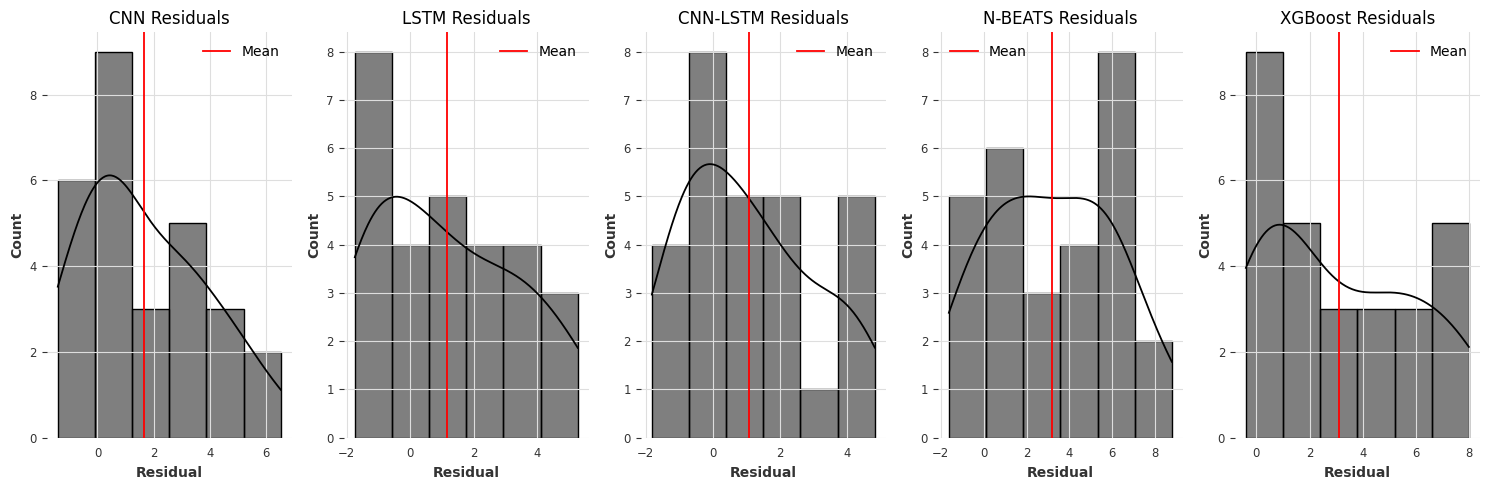

In [14]:

# Step 9: Residual Analysis
cnn_val_resid = true_val - cnn_val_pred
lstm_val_resid = true_val - lstm_val_pred
cnn_lstm_val_resid = true_val - cnn_lstm_val_pred
nbeats_val_resid = true_val - nbeats_val_pred
xgboost_val_resid = true_val - xgboost_val_pred

plt.figure(figsize=(15, 5))
plt.subplot(1, 5, 1)
sns.histplot(x=cnn_val_resid, kde=True)
plt.axvline(x=cnn_val_resid.mean(), color='red', label='Mean')
plt.title('CNN Residuals')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 2)
sns.histplot(x=lstm_val_resid, kde=True)
plt.axvline(x=lstm_val_resid.mean(), color='red', label='Mean')
plt.title('LSTM Residuals')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 3)
sns.histplot(x=cnn_lstm_val_resid, kde=True)
plt.axvline(x=cnn_lstm_val_resid.mean(), color='red', label='Mean')
plt.title('CNN-LSTM Residuals')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 4)
sns.histplot(x=nbeats_val_resid, kde=True)
plt.axvline(x=nbeats_val_resid.mean(), color='red', label='Mean')
plt.title('N-BEATS Residuals')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 5)
sns.histplot(x=xgboost_val_resid, kde=True)
plt.axvline(x=xgboost_val_resid.mean(), color='red', label='Mean')
plt.title('XGBoost Residuals')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


In [15]:

# Step 10: Forecast March-May 2025
forecast_period = 3  # Forecast 3 months
cnn_forecast, lstm_forecast, cnn_lstm_forecast, nbeats_forecast, xgboost_forecast = [], [], [], [], []
last_sequence = norm_df[-best_n_lags:, 0]  # Last sequence from differenced data (up to Dec 2024)
last_value = df['CPI'].iloc[-1]  # Last observed CPI (Jan 2025: 193.4)

# CNN Forecast
current_sequence = last_sequence.copy()
for _ in range(forecast_period):
    current_sequence_reshaped = np.reshape(current_sequence, (1, best_n_lags, 1))
    next_pred = cnn.predict(current_sequence_reshaped, verbose=0)
    cnn_forecast.append(next_pred[0, 0])
    current_sequence = np.append(current_sequence[1:], next_pred[0, 0])

cnn_forecast = inverse_transform_and_undifference(np.array(cnn_forecast).reshape(-1, 1), scaler, last_value)

# LSTM Forecast
current_sequence = last_sequence.copy()
for _ in range(forecast_period):
    current_sequence_reshaped = np.reshape(current_sequence, (1, best_n_lags, 1))
    next_pred = lstm.predict(current_sequence_reshaped, verbose=0)
    lstm_forecast.append(next_pred[0, 0])
    current_sequence = np.append(current_sequence[1:], next_pred[0, 0])

lstm_forecast = inverse_transform_and_undifference(np.array(lstm_forecast).reshape(-1, 1), scaler, last_value)

# CNN-LSTM Forecast
current_sequence = last_sequence.copy()
for _ in range(forecast_period):
    current_sequence_reshaped = np.reshape(current_sequence, (1, best_n_lags, 1))
    next_pred = cnn_lstm.predict(current_sequence_reshaped, verbose=0)
    cnn_lstm_forecast.append(next_pred[0, 0])
    current_sequence = np.append(current_sequence[1:], next_pred[0, 0])

cnn_lstm_forecast = inverse_transform_and_undifference(np.array(cnn_lstm_forecast).reshape(-1, 1), scaler, last_value)

# N-BEATS Forecast
nbeats_forecast_series = nbeats.predict(n=forecast_period, series=TimeSeries.from_values(y_train.flatten()))
nbeats_forecast = inverse_transform_and_undifference(nbeats_forecast_series.values(), scaler, last_value)

# XGBoost Forecast
current_sequence = last_sequence.copy()
for _ in range(forecast_period):
    current_sequence_reshaped = current_sequence.reshape(1, -1)
    next_pred = xgboost.predict(current_sequence_reshaped)
    xgboost_forecast.append(next_pred[0])
    current_sequence = np.append(current_sequence[1:], next_pred[0])

xgboost_forecast = inverse_transform_and_undifference(np.array(xgboost_forecast).reshape(-1, 1), scaler, last_value)

# Forecast DataFrame
forecast_dates = pd.date_range(start='2025-03-31', periods=3, freq='M')  # Mar-May 2025
df_forecasts = pd.DataFrame({
    'date': forecast_dates,
    'cnn': cnn_forecast,
    'lstm': lstm_forecast,
    'cnn_lstm': cnn_lstm_forecast,
    'nbeats': nbeats_forecast,
    'xgboost': xgboost_forecast
})
df_forecasts.set_index('date', inplace=True)
print("\nPredicted CPI for March-May 2025:")
print(df_forecasts)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


Predicted CPI for March-May 2025:
                   cnn        lstm    cnn_lstm      nbeats     xgboost
date                                                                  
2025-03-31  192.753704  193.035829  192.748719  193.415333  193.847302
2025-04-30  193.412198  194.032751  193.754718  193.976485  195.734195
2025-05-31  194.408273  195.312567  194.999492  194.524727  197.658843


/tmp/ipython-input-15-1738800306.py:52: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start='2025-03-31', periods=3, freq='M')  # Mar-May 2025


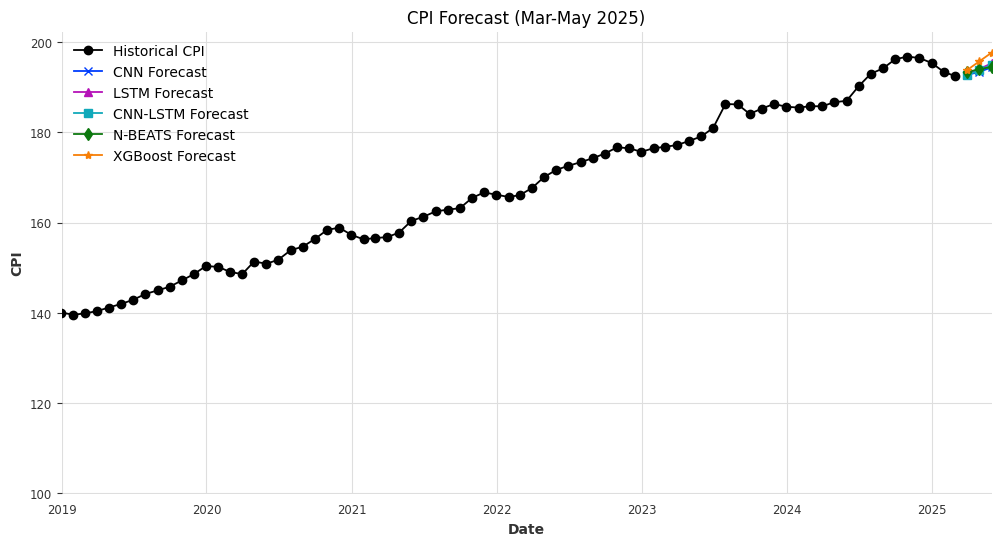


Model Performance Comparison:
      Model      RMSE        R2       MAE      MAPE
0       CNN  2.702312  0.840354  2.050928  1.084095
1      LSTM  2.493899  0.864029  1.995438  1.056550
2  CNN-LSTM  2.179529  0.896149  1.703846  0.901054
3   N-BEATS  4.282342  0.599087  3.501326  1.859055
4   XGBoost  4.171092  0.619647  3.181139  1.670557


In [16]:

# Step 11: Plot Forecasts
plt.figure(figsize=(12, 6))
plt.plot(df['CPI'], label='Historical CPI', marker='o')
plt.plot(df_forecasts.index, df_forecasts['cnn'], label='CNN Forecast', marker='x')
plt.plot(df_forecasts.index, df_forecasts['lstm'], label='LSTM Forecast', marker='^')
plt.plot(df_forecasts.index, df_forecasts['cnn_lstm'], label='CNN-LSTM Forecast', marker='s')
plt.plot(df_forecasts.index, df_forecasts['nbeats'], label='N-BEATS Forecast', marker='d')
plt.plot(df_forecasts.index, df_forecasts['xgboost'], label='XGBoost Forecast', marker='*')
plt.title('CPI Forecast (Mar-May 2025)')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.xlim(pd.Timestamp('2019-01-01'), df_forecasts.index[-1])
plt.legend()
plt.show()

# Step 12: Save Models and Results
cnn.save('cnn_model_india.h5')
lstm.save('lstm_model_india.h5')
cnn_lstm.save('cnn_lstm_model_india.h5')
nbeats.save('nbeats_model_india.pkl')
xgboost.save_model('xgboost_model_india.json')
df_forecasts.to_csv('combined_forecast_india.csv')

# Step 13: Compare Model Performance
model_metrics = {
    'Model': ['CNN', 'LSTM', 'CNN-LSTM', 'N-BEATS', 'XGBoost'],
    'RMSE': [
        np.sqrt(mean_squared_error(true_val, cnn_val_pred)),
        np.sqrt(mean_squared_error(true_val, lstm_val_pred)),
        np.sqrt(mean_squared_error(true_val, cnn_lstm_val_pred)),
        np.sqrt(mean_squared_error(true_val, nbeats_val_pred)),
        np.sqrt(mean_squared_error(true_val, xgboost_val_pred))
    ],
    'R2': [
        r2_score(true_val, cnn_val_pred),
        r2_score(true_val, lstm_val_pred),
        r2_score(true_val, cnn_lstm_val_pred),
        r2_score(true_val, nbeats_val_pred),
        r2_score(true_val, xgboost_val_pred)
    ],
    'MAE': [
        mean_absolute_error(true_val, cnn_val_pred),
        mean_absolute_error(true_val, lstm_val_pred),
        mean_absolute_error(true_val, cnn_lstm_val_pred),
        mean_absolute_error(true_val, nbeats_val_pred),
        mean_absolute_error(true_val, xgboost_val_pred)
    ],
    'MAPE': [
        mean_absolute_percentage_error(true_val, cnn_val_pred) * 100,
        mean_absolute_percentage_error(true_val, lstm_val_pred) * 100,
        mean_absolute_percentage_error(true_val, cnn_lstm_val_pred) * 100,
        mean_absolute_percentage_error(true_val, nbeats_val_pred) * 100,
        mean_absolute_percentage_error(true_val, xgboost_val_pred) * 100
    ]
}
metrics_df = pd.DataFrame(model_metrics)
print("\nModel Performance Comparison:")
print(metrics_df)